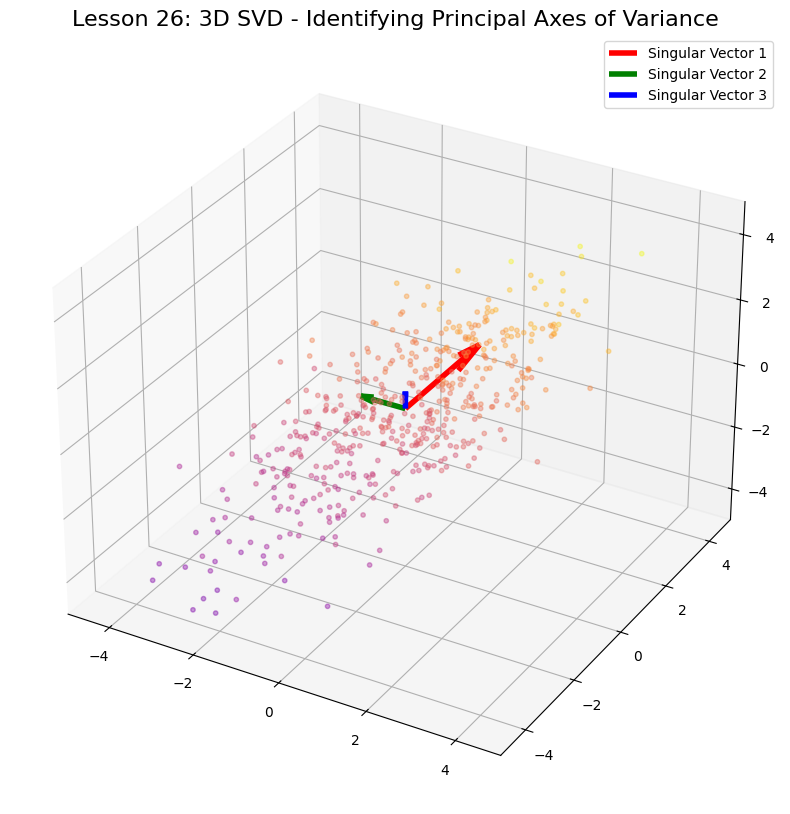

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import os

def run_svd_3d():
    # 3D Veri Kümesi Oluştur (Uzamış bir elipsoid şeklinde nokta bulutu)
    n_points = 500
    x = np.random.normal(0, 1, n_points)
    y = np.random.normal(0, 3, n_points)
    z = np.random.normal(0, 0.5, n_points)
    data = np.vstack([x, y, z])
    
    # SVD Uygula
    U, S, Vt = np.linalg.svd(data, full_matrices=False)
    
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Veri bulutunu çiz
    ax.scatter(data[0], data[1], data[2], c=data[1], cmap='plasma', alpha=0.4, s=10)
    
    # SVD ile bulunan Ana Eksenleri (Singular Vectors) çiz
    colors = ['r', 'g', 'b']
    for i in range(3):
        # U matrisinin sütunları ana yönleri verir, S değerleri uzunluğu verir
        axis = U[:, i] * S[i] / np.sqrt(n_points) # Ölçeklendirilmiş vektör
        ax.quiver(0, 0, 0, axis[0], axis[1], axis[2], color=colors[i], lw=4, label=f'Singular Vector {i+1}')

    ax.set_title("Lesson 26: 3D SVD - Identifying Principal Axes of Variance", fontsize=16)
    ax.set_xlim(-5, 5); ax.set_ylim(-5, 5); ax.set_zlim(-5, 5)
    ax.legend()
    
    if not os.path.exists('../../../assets'): os.makedirs('../../../assets')
    plt.savefig('../../../assets/26_svd_3d.png', dpi=300)
    plt.show()

if __name__ == "__main__":
    run_svd_3d()